First 5 rows of the dataset:
   Area_sqft  Price_lakh
0        650          38
1        800          45
2        950          52
3       1000          55
4       1100          60

Dataset summary:
       Area_sqft  Price_lakh
count      20.00        20.0
mean     1682.50        90.6
std       635.63        32.9
min       650.00        38.0
25%      1175.00        64.5
50%      1650.00        89.0
75%      2137.50       113.5
max      2800.00       148.0

Training samples: 16  Testing samples: 4

Model Coefficient (slope): 0.05181
Model Intercept: 3.30355
Equation: Price = 0.0518 * Area + 3.3036

Actual vs Predicted (test data):
 Area_sqft  Actual_Price  Predicted_Price
       650            38            36.98
      2500           133           132.82
      2250           121           119.87
       800            45            44.75

MAE  : 0.6433
MSE  : 0.6016
RMSE : 0.7756
R2   : 0.9997

Predicted price for 1750 sq. ft.: 93.97 lakh


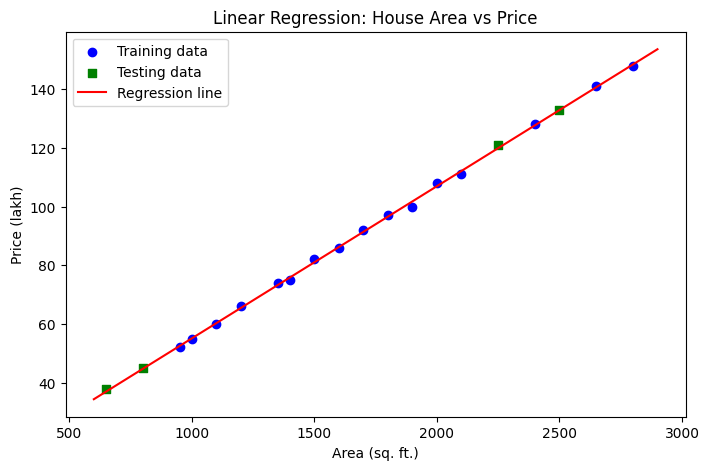

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = {
    'Area_sqft': [650, 800, 950, 1000, 1100, 1200, 1350, 1400, 1500, 1600,
                  1700, 1800, 1900, 2000, 2100, 2250, 2400, 2500, 2650, 2800],
    'Price_lakh': [38, 45, 52, 55, 60, 66, 74, 75, 82, 86,
                   92, 97, 100, 108, 111, 121, 128, 133, 141, 148]
}
df = pd.DataFrame(data)
print("First 5 rows of the dataset:")
print(df.head())
print("\nDataset summary:")
print(df.describe().round(2))

X = df[['Area_sqft']]
y = df['Price_lakh']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)
print("\nTraining samples:", len(X_train), " Testing samples:", len(X_test))

model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Coefficient (slope):", round(model.coef_[0], 5))
print("Model Intercept:", round(model.intercept_, 5))
print(f"Equation: Price = {model.coef_[0]:.4f} * Area + "
      f"{model.intercept_:.4f}")

y_pred = model.predict(X_test)
result = pd.DataFrame({'Area_sqft': X_test['Area_sqft'].values,
                       'Actual_Price': y_test.values,
                       'Predicted_Price': y_pred.round(2)})
print("\nActual vs Predicted (test data):")
print(result.to_string(index=False))

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("\nMAE  :", round(mae, 4))
print("MSE  :", round(mse, 4))
print("RMSE :", round(rmse, 4))
print("R2   :", round(r2, 4))

new_area = pd.DataFrame({'Area_sqft': [1750]})
print("\nPredicted price for 1750 sq. ft.:",
      round(model.predict(new_area)[0], 2), "lakh")

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='green', marker='s', label='Testing data')
line_x = pd.DataFrame({'Area_sqft': np.linspace(600, 2900, 100)})
plt.plot(line_x, model.predict(line_x), color='red',
         label='Regression line')
plt.xlabel("Area (sq. ft.)")
plt.ylabel("Price (lakh)")
plt.title("Linear Regression: House Area vs Price")
plt.legend()
plt.show()
